<a href="https://colab.research.google.com/github/UW-CTRL/lmc-exercises/blob/main/exercises/03a_constrained_optimization_logbarrier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Constrained optimization


Constrained optimization is the task of finding the minimum or maximum of an objective function while satisfying specific restrictions—called constraints—on the variables involved. These constraints, which delineate the set of feasible solutions, can be either equalities (the variable(s) must exactly satisfy some equation) or inequalities (the variable(s) must satisfy upper or lower bounds).

Such problems frequently arise in fields such as engineering, economics, and machine learning, where optimal solutions must comply with real-world limitations and requirements. Some typical examples include:

- **Resource allocation:** In manufacturing, the total quantity of raw materials used cannot exceed what is available (an inequality constraint).
- **Portfolio optimization:** The sum of all investment weights must be exactly 1 (equality constraint), and each weight cannot be negative (inequality constraint).
- **Engineering design:** The stress experienced by a structural component must not surpass a safety threshold (inequality constraint).
- **Logistics:** Delivery routes may need to start and end at a depot (equality constraint), and vehicle capacities must not be exceeded (inequality constraint).

Unlike unconstrained optimization, we cannot simply apply standard gradient descent to constrained problems. The gradient might direct the solution into infeasible regions, violating constraints, and naïve gradient methods offer no mechanism to ensure the solution stays within the allowed set.



In [4]:
from typing import Callable
import jax.numpy as jnp 
import matplotlib.pyplot as plt
import functools
import jax
import numpy as np
import equinox as eqx

## Log-barrier method for solving constrained optimization problems

*(Credit: Oliver Sheridan, Spring 2025)*

In this exercise, we explore how to transform a constrained optimization problem into an unconstrained one using the **log-barrier method**.

Let’s focus on the objective function:

$$
f(x) = (x + 2)^2 + 5\tanh(x)
$$

The task is to find the value of $x$ that minimizes $f(x)$. Numerically, the minimum is achieved at $x^* \approx -2.13578$ with $f(x^*) \approx -4.84389$.

*A noteworthy point*: the derivative $f'(x)$ is transcendental, so the equation $f'(x) = 0$ cannot be solved exactly in closed form. If your gradient descent implementation successfully locates this minimum, you’ve used numerical optimization to rapidly solve a problem that is analytically intractable—a powerful demonstration of these methods.


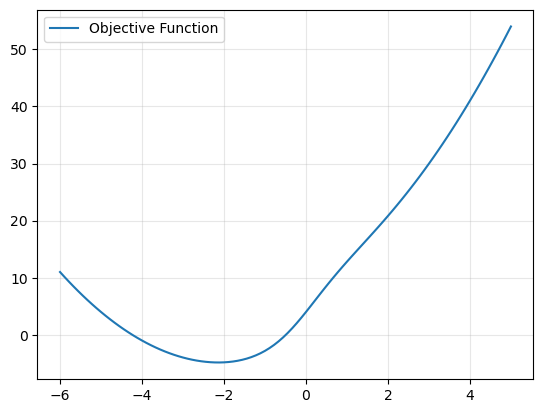

In [5]:
def objective_function(x: jnp.ndarray) -> jnp.ndarray:
    """Objective function to minimize."""
    return (x + 2) ** 2 + 5 * jnp.tanh(x)


xs = jnp.linspace(-6, 5, 100)
plt.plot(xs, objective_function(xs), label="Objective Function")
plt.grid(alpha=0.3)
plt.legend()

### (a) Implement gradient descent on the function to find the minimum.

Use your `gradient_descent` code from `02_unconstrained_optimization` notebook and perform gradient descent on the $f$.

In [8]:
@eqx.filter_jit
def gradient_descent(
    func: Callable[[jnp.ndarray, jnp.ndarray], jnp.ndarray],
    initial_guess: jnp.ndarray,
    learning_rate: float = 0.001,
    num_steps: int = 10000,
):
    """
    Perform gradient descent to find the minimum of the Rosenbrock function.
    Args:
        func: The function to minimize.
        initial_guess: The initial guess.
        learning_rate: The learning rate (step size).
        num_steps: The number of iterations.
    Returns:
        guesses: The list of guesses.
        values: The list of function values.
        sol: The final guess.
    """
    # TODO: implement gradient descent
    ### add your code here
    gradient_func = jax.grad(func, 0)
    
    # JAX METHOD
    batch_func = jax.vmap(func, 0)
    
    def scan_fn(guess, u):
        new_guess = guess - learning_rate * gradient_func(guess)
        return new_guess, new_guess
    
    final_guess, guesses = jax.lax.scan(scan_fn, initial_guess, length=num_steps)
    
    guesses = jnp.concatenate([initial_guess[None], guesses])
    values = batch_func(guesses)

    return guesses, values, final_guess

    ###### end of add your code here



In [16]:
guess = jnp.array(5.0)
learning_rate = 0.01
num_steps = 1000    # increasing from 100 to 1000 
                    # allowed the algorithm to find the minimum much more closely
guesses, values, sol = gradient_descent(
    objective_function, guess, learning_rate, num_steps
)

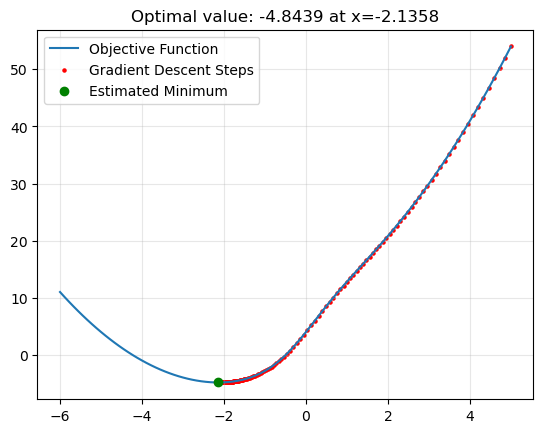

In [17]:
xs = jnp.linspace(-6, 5, 100)
plt.plot(xs, objective_function(xs), label="Objective Function")
plt.scatter(guesses, values, color="red", label="Gradient Descent Steps", s=5)
plt.scatter(
    sol, objective_function(sol), color="green", label="Estimated Minimum", zorder=5
)
plt.title(f"Optimal value: {values[-1]:.4f} at x={sol:.4f}")
plt.grid(alpha=0.3)
plt.legend()

### (b) Applying log-barrier for solving constrained optimization problems

Next, let's consider adding a _constraint_ to our optimization problem—meaning we restrict the set of $x$ values that are allowable solutions. Specifically, we now require that $x$ satisfies an inequality constraint: for a given constraint function $g(x)$, only points where $g(x) < 0$ are considered feasible.

The vanilla gradient descent algorithm cannot enforce such a constraint; $x$ may move freely according to the gradient, potentially violating the requirement $g(x) < 0$. To handle constraints, we need to modify our approach so that the algorithm seeks an optimal solution _within_ the feasible region. One common and powerful technique for this is the _log-barrier method_.

In the log-barrier method, we construct a new objective function $\phi(x)$ from the original objective $f(x)$, designed to:
 - Approximate $f(x)$ whenever $x$ is comfortably inside the feasible region (i.e., $g(x)$ is well below $0$).
 - Rapidly increase to infinity as $x$ approaches the boundary $g(x) = 0$, effectively preventing the optimizer from stepping outside the feasible region.

This is achieved by defining:
$$
\phi(x) = f(x) - \frac{1}{t} \ln(-g(x)),
$$
where $t > 0$ is a parameter that controls how strictly the barrier is enforced.

For this part, suppose we want to minimize our earlier objective function $f(x) = (x + 2)^2 + 5\tanh (x)$, but now subject to the constraint $x > 1$. That is, $g(x) = 1 - x$, and we seek $x$ such that $g(x) < 0$.


Implement the new objective function with the log barrier applied on the constraint.

Hint: for your `phi` function to work well with the next parts of this problem, be sure to use `jnp.log` instead of `np.log`.

In [36]:
def objective_log_barrier(
    x: jnp.ndarray, g: Callable[[jnp.ndarray], jnp.ndarray], t: float = 1.0
) -> jnp.ndarray:
    """Objective function with log barrier for the constraint x <= 2."""
    #### add your code here
    obj = (x + 2) ** 2 + 5 * jnp.tanh(x)
    phi =  obj - 1/t * jnp.log(-g(x))
    return phi
    ### end of add your code here

# testing
def g(x):
    return 1 - x
objective_log_barrier(0, g) # gives a nan output

Array(nan, dtype=float32, weak_type=True)

### (c) Plot $\phi(x)$.

Plot $\phi(x)$ for $t = 0.5,\ 2,\ 5$. Comment on how $\phi(x)$ changes with changing $t$.

Note that since $\ln(y)$ is not defined (in the real numbers) for $y \le 0$, the domain of $\phi(x)$ is restricted to $x > 1$.


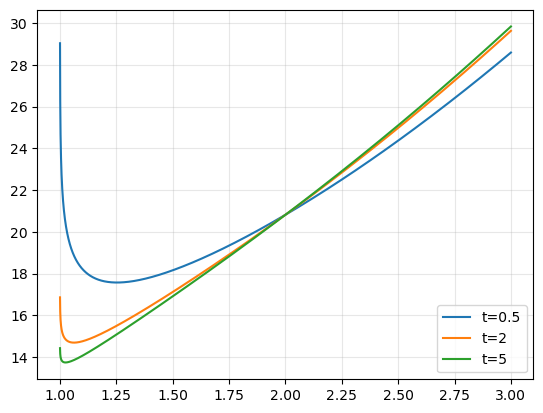

In [34]:
def g(x):
    return 1 - x

# xs = jnp.linspace(1.00001, 3, 10000)
xs = jnp.linspace(0, 3, 10000)

plt.plot(xs, objective_log_barrier(xs, g, t=0.5), label="t=0.5")
plt.plot(xs, objective_log_barrier(xs, g, t=2), label="t=2")
plt.plot(xs, objective_log_barrier(xs, g, t=5), label="t=5")
plt.grid(alpha=0.3)
plt.legend()

### (c) Apply Gradient Descent and Visualize the Results

Perform gradient descent optimization on the log-barrier objective function $\phi(x)$ for several values of the barrier parameter $t$ (e.g., $t = 0.5$, $2$, and $5$).
Generate plots showing both the trajectories of the optimization and the final solutions for each $t$.


In [37]:
guess = jnp.array(3.0)
learning_rate = 0.01
num_steps = 500

obj_05 = functools.partial(objective_log_barrier, g=g, t=0.5)
obj_2 = functools.partial(objective_log_barrier, g=g, t=2)
obj_5 = functools.partial(objective_log_barrier, g=g, t=5)


guesses_05, values_05, sol_05 = gradient_descent(
    obj_05, guess, learning_rate, num_steps
)
guesses_2, values_2, sol_2 = gradient_descent(obj_2, guess, learning_rate, num_steps)
guesses_5, values_5, sol_5 = gradient_descent(obj_5, guess, learning_rate, num_steps)

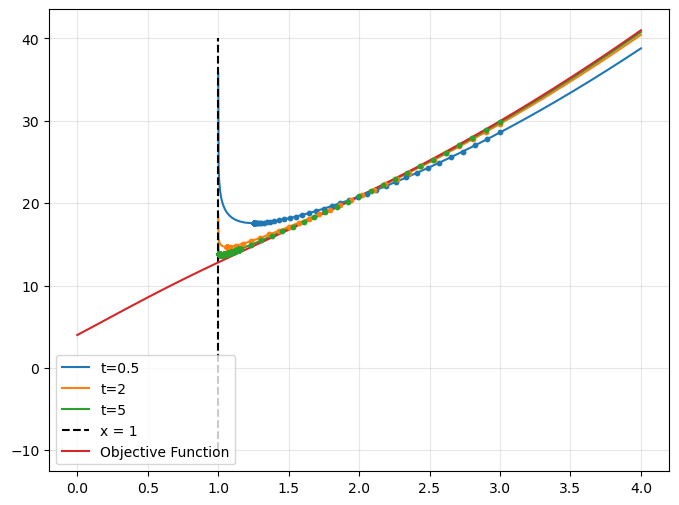

In [38]:
plt.figure(figsize=(8, 6))

xs = jnp.linspace(1.00001, 4, 1000)
plt.plot(xs, obj_05(xs), label="t=0.5")
plt.plot(xs, obj_2(xs), label="t=2")
plt.plot(xs, obj_5(xs), label="t=5")

plt.scatter(guesses_05, obj_05(guesses_05), zorder=5, s=10)
plt.scatter(guesses_2, obj_2(guesses_2), zorder=5, s=10)
plt.scatter(guesses_5, obj_5(guesses_5), zorder=5, s=10)
plt.vlines(1, -10, 40, linestyles="dashed", label="x = 1", color="black")


xs = jnp.linspace(0, 4, 100)
plt.plot(xs, objective_function(xs), label="Objective Function")

plt.grid(alpha=0.3)
plt.legend()